# Credit-card fraud — isolation forest

One small experiment a day. Seed fixed for reproducibility.

Unsupervised angle: can IsolationForest flag the rare fraud cases without ever seeing labels?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1106

rng = np.random.RandomState(SEED)
n = 4000
n_fraud = 90
amount = np.clip(rng.lognormal(3.2, 1.1, size=n), 1, 5000).round(2)
hour = rng.randint(0, 24, size=n)
merchant = rng.choice(["grocery", "gas", "online", "travel", "food"], size=n,
                      p=[0.35, 0.20, 0.25, 0.08, 0.12])
is_fraud = np.zeros(n, dtype=int)
fidx = rng.choice(n, n_fraud, replace=False)
is_fraud[fidx] = 1
# fraud looks different: unusually large amounts, odd hours, online/travel
amount[fidx] = np.clip(rng.lognormal(6.2, 0.7, n_fraud), 60, 9000).round(2)
hour[fidx] = rng.choice([0, 1, 2, 3, 4, 22, 23], size=n_fraud)
merchant[fidx] = rng.choice(["online", "travel"], size=n_fraud, p=[0.8, 0.2])
df = pd.DataFrame({"Amount": amount, "Hour": hour, "Merchant": merchant,
                   "Fraud": is_fraud})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nfraud rate: %.4f" % df["Fraud"].mean())


shape: (4000, 4)
   Amount  Hour Merchant  Fraud
0  589.09    16     food      0
1  665.82    23   travel      1
2   14.55     6   online      0

fraud rate: 0.0225


## Contamination sweep

contamination 0.005: flagged   20 | precision 0.700 | recall 0.156
contamination 0.010: flagged   40 | precision 0.600 | recall 0.267
contamination 0.020: flagged   80 | precision 0.487 | recall 0.433
contamination 0.050: flagged  200 | precision 0.335 | recall 0.744


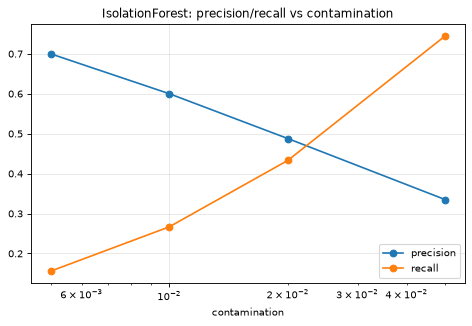

In [ ]:

X = pd.get_dummies(df[["Amount", "Hour", "Merchant"]], columns=["Merchant"]).values
y = df["Fraud"].values
recs, precs, conts = [], [], [0.005, 0.01, 0.02, 0.05]
for c in conts:
    iso = IsolationForest(contamination=c, random_state=SEED)
    pred = (iso.fit_predict(X) == -1).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum())
    prec = tp / max(pred.sum(), 1); rec = tp / max(y.sum(), 1)
    precs.append(prec); recs.append(rec)
    print(f"contamination {c:.3f}: flagged {pred.sum():4d} | precision {prec:.3f} | recall {rec:.3f}")
fig, ax = plt.subplots()
ax.plot(conts, precs, marker="o", label="precision")
ax.plot(conts, recs, marker="o", label="recall")
ax.set_xscale("log"); ax.set_xlabel("contamination")
ax.legend(); ax.set_title("IsolationForest: precision/recall vs contamination")


## Where do the flagged transactions sit?

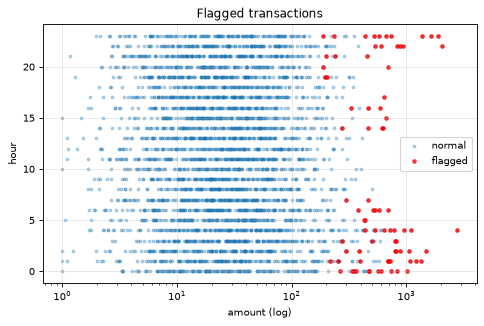

In [ ]:

iso = IsolationForest(contamination=0.02, random_state=SEED)
flagged = (iso.fit_predict(X) == -1)
fig, ax = plt.subplots()
ax.scatter(df["Amount"], df["Hour"], s=6, alpha=0.3, label="normal")
ax.scatter(df.loc[flagged, "Amount"], df.loc[flagged, "Hour"], s=10, c="red", alpha=0.7, label="flagged")
ax.set_xscale("log"); ax.set_xlabel("amount (log)"); ax.set_ylabel("hour")
ax.legend(); ax.set_title("Flagged transactions")


## What I learned

- Unsupervised detection finds a chunk of fraud, but precision is weak — big legitimate purchases look identical.
- Contamination ≈ true rate is the sweet spot; overshooting just adds noise.
- Next: supervised model with the labels (sanity check on the ceiling).